# Feature Extraction in NLP: TF-IDF & Word Embeddings

Welcome to Day 3-4 of Week 1! In this notebook, you'll learn about feature extraction methods in NLP, focusing on TF-IDF and the basics of word embeddings.

## 1. Introduction to Feature Extraction

Feature extraction transforms raw text into numerical representations that machine learning models can understand. Two common approaches are:
- **TF-IDF (Term Frequency-Inverse Document Frequency)**
- **Word Embeddings (Word2Vec, GloVe, spaCy vectors, etc.)**

## 2. TF-IDF

TF-IDF reflects how important a word is to a document in a collection.
- **Term Frequency (TF):** How frequently a word appears in a document.
- **Inverse Document Frequency (IDF):** How unique or rare a word is across all documents.



How TF-IDF works? Lets take a look more in details here:

1. **Calculate TF (Term Frequency):**
   - $\mathrm{TF}(t, d) = \frac{\text{Number of times } t \text{ appears in } d}{\text{Total number of terms in } d}$

2. **Calculate IDF (Inverse Document Frequency):**
   - $\mathrm{IDF}(t) = \log\left(\frac{1+N}{1+n_t}\right) + 1$
   - $N$ = total number of documents
   - $n_t$ = number of documents containing the term $t$

3. **Multiply TF and IDF:**
   - $\mathrm{TF\text{-}IDF}(t, d) = \mathrm{TF}(t, d) \times \mathrm{IDF}(t)$

**NB**: The method **TfidfVectorizer** remove single characters before computation.


Let's see how to compute TF-IDF using scikit-learn.

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

corpus = [
    'I love natural language processing',
    'Language models are amazing',
    'I love learning about NLP',
    'NLP is fun and powerful'
]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df

,about,amazing,and,are,fun,is,language,learning,love,models,natural,nlp,powerful,processing
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.437791,0.000000,0.437791,0.000000,0.555283,0.000000,0.000000,0.555283
1,0.000000,0.525473,0.000000,0.525473,0.000000,0.000000,0.414289,0.000000,0.000000,0.525473,0.000000,0.000000,0.000000,0.000000
2,0.555283,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.555283,0.437791,0.000000,0.000000,0.437791,0.000000,0.000000
3,0.000000,0.000000,0.465162,0.000000,0.465162,0.465162,0.000000,0.000000,0.000000,0.000000,0.000000,0.366739,0.465162,0.000000


### Visualizing TF-IDF

Let's visualize the TF-IDF scores for the first document.

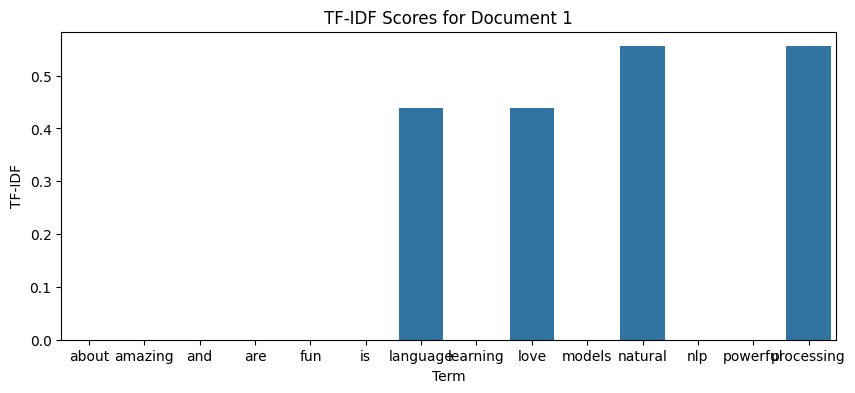

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

tfidf_scores = df.iloc[0]
plt.figure(figsize=(10, 4))
sns.barplot(x=tfidf_scores.index, y=tfidf_scores.values)
plt.title('TF-IDF Scores for Document 1')
plt.ylabel('TF-IDF')
plt.xlabel('Term')
plt.show()

## 3. Word Embeddings Basics

Word embeddings represent words as dense vectors in a continuous space, capturing semantic relationships.
Popular methods include Word2Vec, GloVe, and spaCy's built-in vectors.

In [5]:
import spacy
import warnings

warnings.filterwarnings('ignore')

# download the model:
spacy.cli.download("en_core_web_sm") # alternative download it in bash "python -m spacy download en_core_web_sm"

# Load spaCy's small English model
nlp = spacy.load('en_core_web_sm')

word = 'language'
vector = nlp(word).vector
print(f'Embedding for "{word}":', vector)
print('Vector shape:', vector.shape)

c:\Users\piers\Desktop\home\Sviluppo\text-llm-learning\.conda\lib\site-packages\jsonschema\__init__.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


✔ Download and installation successful
You can now load the model via spacy.load('en_core_web_sm')
Embedding for "language": [ 0.04581422  1.7837591   1.1892208  -1.3746394   0.61221933 -1.6086303
  0.60945284  0.21488982 -2.3966312   2.4785702   0.48625612  1.0816121
  0.9065566  -0.17961699  0.7995978  -1.4440398  -0.6056777   2.0052817
 -1.3493967   1.1407906   1.2561283  -0.2448098  -0.58362496 -1.0788186
 -0.55910456  0.5996211  -0.21914765 -3.128593    0.7907949  -2.2692902
 -0.81634307 -1.0102202   0.70114475 -1.2753897  -1.4168129   2.0454175
  0.04271227 -1.7256416  -0.3600208  -0.9409242   4.4227285   0.8718259
  0.6833502  -1.6946768   2.4377606  -0.81222147  1.2033842   0.6494031
 -0.5426538  -0.25800976 -1.0186487  -0.09554024 -1.2056634  -2.240632
 -2.7108824   2.429046    2.6212873   0.5129653  -0.93962705  0.04755461
 -0.6311324   0.14951468  0.07533494 -2.5221345   2.6191325   3.6503658
  0.65836656 -0.86742663  0.7794337   1.1504283   0.0895814   1.5464025
  0.8828202

### Visualizing Word Embeddings (PCA)

Let's visualize embeddings for a few words using PCA.

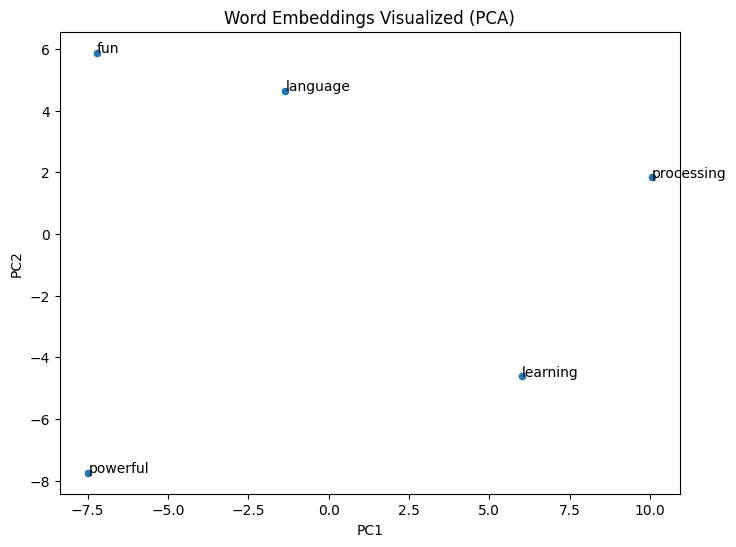

In [7]:
from sklearn.decomposition import PCA
import numpy as np

words = ['language', 'processing', 'learning', 'fun', 'powerful']
vectors = np.array([nlp(w).vector for w in words])

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1])
for i, word in enumerate(words):
    plt.text(reduced[i,0]+0.01, reduced[i,1]+0.01, word)
plt.title('Word Embeddings Visualized (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()




## 4. Exercises

1. **TF-IDF Practice:** Try changing the corpus and observe how the TF-IDF scores change.
2. **Word Embeddings Practice:** Pick your own set of words and visualize their embeddings.
3. (Optional) Try using Gensim's Word2Vec on a custom corpus.